# IY034 – SupCon Backbone Refinement → SVM

**Goal:** Use labeled experimental data to refine the SimCLR backbone via **Supervised Contrastive
(SupCon) loss**, then classify with a frozen-backbone SVM — benchmarked against IY031's
unrefined SimCLR + SVM baseline.

**Why SupCon over CE finetuning (which failed in IY030):**  
SupCon uses a metric-learning signal (pull same-class embeddings together, push others apart)
rather than fitting class logits. It is far more robust to small N and does not catastrophically
forget pretrained structure.

**Two-stage pipeline:**  
```
Stage 1:  SimCLR checkpoint → SupCon refinement on augmented experimental data
          (backbone + projection head updated; labels used)
Stage 2:  Refined backbone (frozen) → encode → StandardScale → RBF-SVM
```

**Augmentations** (applied per mini-batch to create 2 independent views):
- Gaussian noise σ = 0.05
- Amplitude scaling × U(0.9, 1.1) per sample  
- Random circular temporal shift Δt ∈ U(−5, 5) timepoints

**Baseline:** IY031 results (`IY031_tf_condition_{ss,full}_simclr_results.csv`).

**Dataset / split / checkpoints:** identical to IY031 (6-class Nrg1/Rtg1 × glucose,
exp 18446 excluded, stratified 80/20, seed 42).

In [1]:
import re
import sys
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from functools import partial
from matplotlib.patches import Patch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from training.supcon import supcon_loss
from utils.embeddings import (
    load_simclr_model, encode_channel, parse_arch_from_name,
    make_checkpoint_short_label, make_unique_checkpoint_label,
)

RANDOM_STATE = 42
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIXED_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}
make_short_label  = partial(make_checkpoint_short_label,  norm_overrides=NORM_OVERRIDES)
make_unique_label = partial(make_unique_checkpoint_label, norm_overrides=NORM_OVERRIDES)

IY034_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY034")
IY031_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY031")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]
EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
CKPT_DIRS     = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]

# Number of top IY031 checkpoints to refine (ranked by Full LP accuracy)
TOP_N_CHECKPOINTS = 5

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Data Loading (identical to IY031)

In [2]:
from utils.experimental_time_series import load_labelled_time_series_csvs
from utils.processing.pipeline import prepare_dataset

metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)
LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

def load_dataset(data_dir: Path):
    return load_labelled_time_series_csvs(
        data_dir=data_dir, file_re=FILE_RE, label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS, excluded_exps=EXCLUDED_EXPS,
    )

ss_ts_raw,   ss_label_strs   = load_dataset(SS_DATA_DIR)
full_ts_raw, full_label_strs = load_dataset(FULL_DATA_DIR)

print("--- Steady-state ---")
ss   = prepare_dataset(ss_ts_raw,   ss_label_strs,   FIXED_CLASSES, "Steady-state", RANDOM_STATE)
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, FIXED_CLASSES, "Full",         RANDOM_STATE)

  18360/1106/GFP       -> Mig2 @ 0.1% glucose                            (233 cells, 122 tp)
  18360/1106/mCherry   -> Mig1 @ 0.1% glucose                            (233 cells, 23 tp)
  18360/898/GFP       -> Msn2 @ 0.1% glucose                            (254 cells, 116 tp)
  18360/898/mCherry   -> Mig1 @ 0.1% glucose                            (254 cells, 24 tp)
  18360/900/GFP       -> Mig1 @ 0.1% glucose                            (243 cells, 63 tp)
  18360/900/mCherry   -> Msn2 @ 0.1% glucose                            (243 cells, 178 tp)
  18464/756/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (209 cells, 201 tp)
  18464/756/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (209 cells, 237 tp)
  18464/764/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (202 cells, 178 tp)
  18464/764/mCherry   -> Dot6 @ 2% glucose (mock/steady)                (202 cells, 129 tp)
  18464/903/GFP       -> Dot6 @ 2% glucose (mock/steady)                (220 cell

## 2. IY031 Baseline & Checkpoint Selection

In [3]:
ss_lp_df   = pd.read_csv(IY031_DIR / "IY031_tf_condition_ss_simclr_results.csv")
full_lp_df = pd.read_csv(IY031_DIR / "IY031_tf_condition_full_simclr_results.csv")

ss_lp_best   = ss_lp_df[ss_lp_df["status"]=="ok"]["accuracy"].max()
full_lp_best = full_lp_df[full_lp_df["status"]=="ok"]["accuracy"].max()
chance       = 1.0 / len(FIXED_CLASSES)

print(f"IY031 best LP -- SS:   {ss_lp_best:.4f}")
print(f"IY031 best LP -- Full: {full_lp_best:.4f}")
print(f"Chance: {chance:.4f}")

# Top-N checkpoints ranked by Full LP accuracy (same checkpoints across both datasets)
top_ckpts = (
    full_lp_df[full_lp_df["status"]=="ok"]
    .sort_values("accuracy", ascending=False)
    .head(TOP_N_CHECKPOINTS)
    .reset_index(drop=True)
)
print(f"\nTop {TOP_N_CHECKPOINTS} checkpoints (by Full LP acc):")
for _, r in top_ckpts.iterrows():
    print(f"  {r['label']:<52s}  LP_full={r['accuracy']:.4f}")

IY031 best LP -- SS:   0.7234
IY031 best LP -- Full: 0.7979
Chance: 0.1667

Top 5 checkpoints (by Full LP acc):
  IY024-batch b64 D16 122627                            LP_full=0.7979
  IY017-inst b512 D16 154043                            LP_full=0.7872
  IY023-batch b1024 D16 183509                          LP_full=0.7766
  IY017-inst b256 D16 154425                            LP_full=0.7766
  IY023-batch b64 D16 104312                            LP_full=0.7660


## 3. Augmentation Helper

Three lightweight time-series augmentations applied independently to each view.
All operate on batch-wise z-scored arrays `X` of shape `(N, T)` — same normalisation
as IY031/IY030.

In [4]:
def augment_batch(
    X: np.ndarray,
    rng: np.random.Generator,
    noise_std: float = 0.05,
    scale_range: tuple = (0.9, 1.1),
    max_shift: int = 5,
) -> np.ndarray:
    """Apply 3 stochastic augmentations to a batch of time series.

    - Gaussian noise: adds independent N(0, noise_std²) to every timepoint.
    - Amplitude scaling: multiplies each trace by a per-sample U(scale_range) scalar.
    - Circular temporal shift: rolls each trace by a per-sample Δt ∈ U(-max_shift, max_shift).

    Parameters
    ----------
    X : (N, T) float array — batch-wise z-scored time series.
    rng : numpy Generator — caller controls the seed per view for reproducibility.

    Returns
    -------
    (N, T) float array — augmented copy (X is not modified in place).
    """
    X = X.copy()
    N, T = X.shape
    # Gaussian noise
    X += rng.normal(0, noise_std, size=X.shape).astype(X.dtype)
    # Per-sample amplitude scaling
    scales = rng.uniform(*scale_range, size=(N, 1)).astype(X.dtype)
    X *= scales
    # Per-sample circular temporal shift
    shifts = rng.integers(-max_shift, max_shift + 1, size=N)
    for i, s in enumerate(shifts):
        if s != 0:
            X[i] = np.roll(X[i], s)
    return X

## 4. Stage 1 — SupCon Backbone Refinement

For each mini-batch:
1. Create 2 independently augmented views of every sample.
2. Encode both through backbone → project through projection head.
3. Concatenate `[z1; z2]` (shape 2B × D) with duplicated labels `[y; y]`.
4. Apply `supcon_loss` — pulls same-class embeddings together, pushes others apart.

No val split is needed: SupCon optimises the embedding geometry, not class logits,
so it is far less prone to overfitting. Early stopping uses a plateau in training loss.

In [5]:
def train_supcon_refinement(
    simclr_model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    n_epochs: int = 200,
    batch_size: int = 64,
    lr: float = 1e-4,
    weight_decay: float = 1e-3,
    temperature: float = 0.07,
    patience: int = 30,
    noise_std: float = 0.05,
    scale_range: tuple = (0.9, 1.1),
    max_shift: int = 5,
    device=DEVICE,
    seed: int = RANDOM_STATE,
):
    """Stage 1: refine backbone + projection head with SupCon loss on augmented experimental data.

    Two augmented views per sample are created per mini-batch using augment_batch().
    Returns the refined SSL_Transformer model (deep copy; original is untouched) and
    the per-epoch loss curve.
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    model = copy.deepcopy(simclr_model).to(device)
    model.train()

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    # Simple index-based DataLoader — augmentation applied on CPU before transfer
    idx_t  = torch.arange(len(y_train))
    y_t    = torch.from_numpy(y_train).long()
    loader = DataLoader(
        TensorDataset(idx_t, y_t),
        batch_size=batch_size, shuffle=True, drop_last=False,
    )

    best_loss  = float("inf")
    best_state = None
    no_improve = 0
    loss_curve = []

    for epoch in range(n_epochs):
        ep_loss = 0.0
        for idx_b, yb in loader:
            X_b = X_train[idx_b.numpy()]              # (B, T) numpy
            # Two independently augmented views
            x1 = augment_batch(X_b, rng, noise_std, scale_range, max_shift)
            x2 = augment_batch(X_b, rng, noise_std, scale_range, max_shift)
            # (B, T, 1) float tensors
            x1t = torch.from_numpy(x1).float().unsqueeze(-1).to(device)
            x2t = torch.from_numpy(x2).float().unsqueeze(-1).to(device)
            ybt = yb.to(device)

            opt.zero_grad()
            h1 = model.backbone.encode(x1t)           # (B, d_model)
            h2 = model.backbone.encode(x2t)
            z1 = model.projection_head(h1)             # (B, d_model)
            z2 = model.projection_head(h2)
            # Concatenate views; duplicate labels so same-class = both views of same sample
            features = torch.cat([z1, z2], dim=0)     # (2B, d_model)
            labels   = torch.cat([ybt, ybt], dim=0)   # (2B,)
            loss = supcon_loss(features, labels, temperature=temperature)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * len(ybt)

        sched.step()
        ep_loss /= len(y_train)
        loss_curve.append(ep_loss)

        if ep_loss < best_loss:
            best_loss  = ep_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    return model, loss_curve

## 5. Stage 2 — Frozen Backbone → SVM (identical to IY031)

In [6]:
def run_svm(Z_tr, Z_te, y_tr, y_te):
    """StandardScale → RBF-SVM; mirrors IY031 exactly."""
    sc  = StandardScaler()
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(sc.fit_transform(Z_tr), y_tr)
    y_pred = clf.predict(sc.transform(Z_te))
    return accuracy_score(y_te, y_pred), y_pred


def encode(model, X, device=DEVICE):
    """Encode (N, T) array through frozen backbone; returns (N, d_model)."""
    return encode_channel(model, X, device)

## 6. Run: SupCon Refinement → SVM vs IY031 Baseline

In [7]:
def run_all(d: dict, dataset_tag: str, lp_df: pd.DataFrame, csv_tag: str):
    """For each top-N checkpoint: baseline SVM → SupCon refine → refined SVM."""
    n_cls  = len(d["class_names"])
    rows, preds = [], {}

    print(f"\n{'='*70}")
    print(f"{dataset_tag} ({n_cls} classes)")
    print(f"{'='*70}")
    print(f"  {'checkpoint':<52s}  {'LP-SVM':>7s}  {'SC-SVM':>7s}  {'Δ':>7s}  epochs")

    for _, row in top_ckpts.iterrows():
        ckpt  = Path(row["checkpoint"])
        label = row["label"]
        # IY031 LP accuracy for this checkpoint on this dataset
        lp_row = lp_df[lp_df["label"] == label]
        lp_acc = float(lp_row["accuracy"].values[0]) if len(lp_row) > 0 else np.nan

        try:
            # ── Stage 2 on unrefined model (IY031 baseline, recomputed for consistency) ──
            simclr = load_simclr_model(ckpt, DEVICE)
            Z_tr_base = encode(simclr, d["X_train"])
            Z_te_base = encode(simclr, d["X_test"])
            base_acc, base_pred = run_svm(Z_tr_base, Z_te_base, d["y_train"], d["y_test"])

            # ── Stage 1: SupCon refinement ──
            refined, loss_curve = train_supcon_refinement(
                simclr, d["X_train"], d["y_train"]
            )

            # ── Stage 2 on refined model ──
            Z_tr_ref = encode(refined, d["X_train"])
            Z_te_ref = encode(refined, d["X_test"])
            ref_acc, ref_pred = run_svm(Z_tr_ref, Z_te_ref, d["y_train"], d["y_test"])

            delta = ref_acc - base_acc
            print(f"  {label:<52s}  {base_acc:.4f}  {ref_acc:.4f}  {delta:+.4f}  {len(loss_curve)}ep")

            preds[str(ckpt)] = {"baseline": base_pred, "supcon": ref_pred}
            rows.append({
                "label":       label,
                "checkpoint":  str(ckpt),
                "dataset":     dataset_tag,
                "lp_acc":      lp_acc,
                "baseline_acc": base_acc,
                "supcon_acc":  ref_acc,
                "delta":       delta,
                "n_epochs":    len(loss_curve),
                "final_loss":  loss_curve[-1],
                "status":      "ok",
            })
        except Exception as exc:
            print(f"  {label:<52s}  FAILED: {exc}")
            rows.append({"label": label, "checkpoint": str(ckpt), "dataset": dataset_tag,
                         "status": "failed",
                         "lp_acc": np.nan, "baseline_acc": np.nan,
                         "supcon_acc": np.nan, "delta": np.nan})

    df = (pd.DataFrame(rows)
            .sort_values("supcon_acc", ascending=False, na_position="last")
            .reset_index(drop=True))
    df.drop(columns=["lp_acc"], errors="ignore")  # lp_acc kept in df for plotting
    df.to_csv(IY034_DIR / f"IY034_{csv_tag}_supcon_svm_results.csv", index=False)
    print(f"\nSaved: IY034_{csv_tag}_supcon_svm_results.csv")
    return df, preds


ss_df,   ss_preds   = run_all(ss,   "Steady-state", ss_lp_df,   "ss")
full_df, full_preds = run_all(full, "Full",          full_lp_df, "full")


Steady-state (6 classes)
  checkpoint                                             LP-SVM   SC-SVM        Δ  epochs


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  IY024-batch b64 D16 122627                            0.6809  0.6809  +0.0000  200ep


  IY017-inst b512 D16 154043                            0.6809  0.6383  -0.0426  164ep


  IY023-batch b1024 D16 183509                          0.6277  0.6596  +0.0319  163ep


...

  IY024-batch b64 D16 122627                            0.7979  0.8404  +0.0426  200ep


  IY017-inst b512 D16 154043                            0.7979  0.7872  -0.0106  168ep


  IY023-batch b1024 D16 183509                          0.7660  0.7128  -0.0532  154ep


  IY017-inst b256 D16 154425                            0.6702  0.7660  +0.0957  119ep


  IY023-batch b64 D16 104312                            0.7553  0.7553  +0.0000  200ep

Saved: IY034_full_supcon_svm_results.csv


## 7. Training Loss Curves (best checkpoint)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY034/IY034_ss_supcon_loss_curve.png


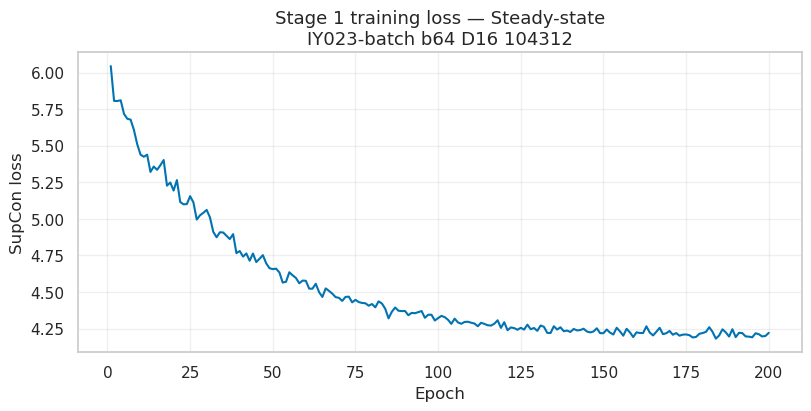

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY034/IY034_full_supcon_loss_curve.png


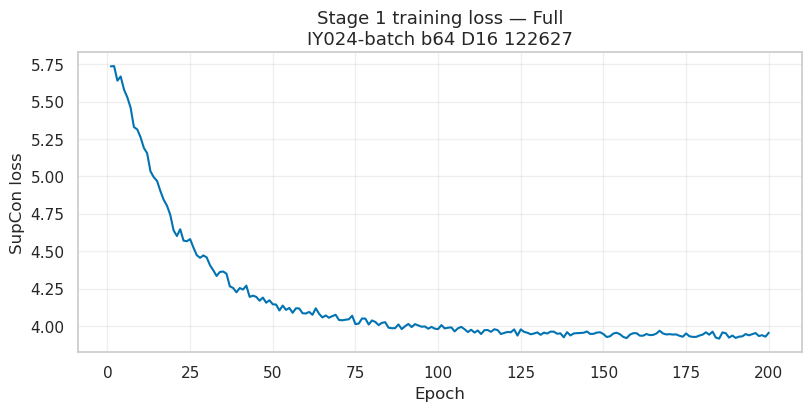

In [8]:
def plot_loss_curve(d, dataset_tag, csv_tag):
    """Rerun Stage 1 for the best SupCon checkpoint and plot its training loss."""
    best_row = (full_df if csv_tag == "full" else ss_df).iloc[0]
    ckpt     = Path(best_row["checkpoint"])
    simclr   = load_simclr_model(ckpt, DEVICE)
    _, loss_curve = train_supcon_refinement(simclr, d["X_train"], d["y_train"])

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(np.arange(1, len(loss_curve)+1), loss_curve,
            color=sns.color_palette("colorblind")[0])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("SupCon loss")
    ax.set_title(f"Stage 1 training loss — {dataset_tag}\n{best_row['label']}", fontsize=13)
    ax.grid(alpha=0.3)
    fig_path = IY034_DIR / f"IY034_{csv_tag}_supcon_loss_curve.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()

plot_loss_curve(ss,   "Steady-state", "ss")
plot_loss_curve(full, "Full",         "full")

## 8. Per-Checkpoint Comparison (Baseline SVM vs SupCon SVM)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY034/IY034_ss_per_checkpoint_comparison.png


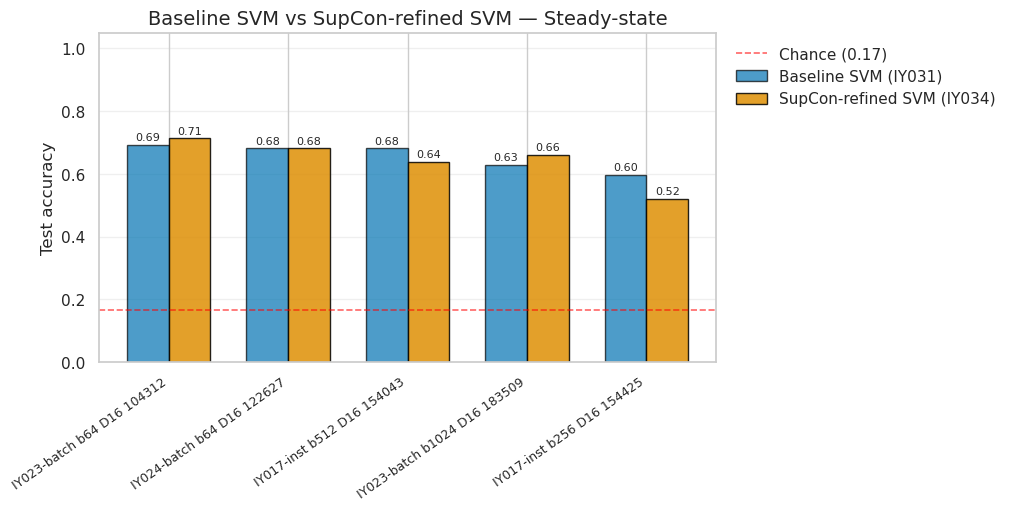

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY034/IY034_full_per_checkpoint_comparison.png


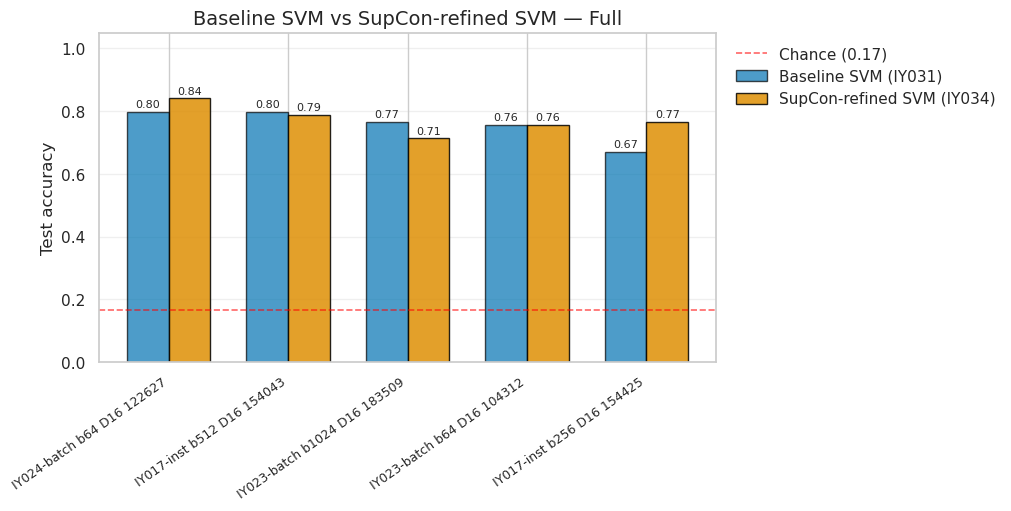

In [9]:
def plot_per_checkpoint(df, dataset_tag, fig_path):
    """Side-by-side bars: baseline SVM vs SupCon-refined SVM per checkpoint."""
    v  = df[df["status"]=="ok"].sort_values("baseline_acc", ascending=False)
    x  = np.arange(len(v))
    w  = 0.35
    pal = sns.color_palette("colorblind")

    fig, ax = plt.subplots(figsize=(max(10, len(v)*1.5), 5), constrained_layout=True)
    b1 = ax.bar(x - w/2, v["baseline_acc"], width=w, color=pal[0], alpha=0.7,
                edgecolor="black", label="Baseline SVM (IY031)")
    b2 = ax.bar(x + w/2, v["supcon_acc"],  width=w, color=pal[1], alpha=0.85,
                edgecolor="black", label="SupCon-refined SVM (IY034)")
    for bar, val in zip(b1, v["baseline_acc"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    for bar, val in zip(b2, v["supcon_acc"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(chance, color="red", ls="--", lw=1.2, alpha=0.6,
               label=f"Chance ({chance:.2f})")
    ax.set_xticks(x)
    ax.set_xticklabels(v["label"], rotation=35, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"Baseline SVM vs SupCon-refined SVM — {dataset_tag}", fontsize=14)
    ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", frameon=False)
    ax.grid(axis="y", alpha=0.3)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()

plot_per_checkpoint(ss_df,   "Steady-state",
                   IY034_DIR / "IY034_ss_per_checkpoint_comparison.png")
plot_per_checkpoint(full_df, "Full",
                   IY034_DIR / "IY034_full_per_checkpoint_comparison.png")

## 9. Summary: Best Baseline SVM vs Best SupCon SVM

SUMMARY — best accuracy across top-N checkpoints
Method                                SS      Full
Baseline SVM (IY031)              0.7234    0.7979
SupCon-refined SVM (IY034)        0.7128    0.8404
Δ (SupCon − Baseline)            -0.0106   +0.0426
Chance                            0.1667    0.1667
Saved: IY034_summary_supcon_vs_baseline.png


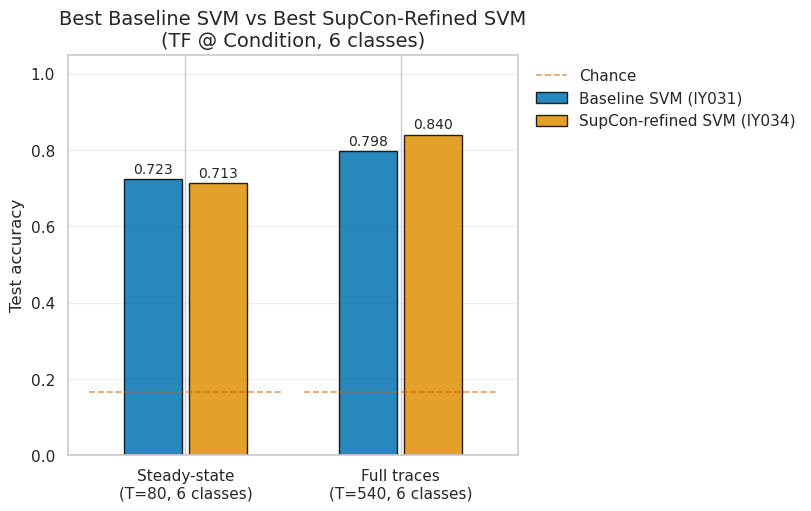

In [10]:
def ok(df): return df[df["status"]=="ok"]

ss_base_best   = ok(ss_df)["baseline_acc"].max()
ss_sc_best     = ok(ss_df)["supcon_acc"].max()
full_base_best = ok(full_df)["baseline_acc"].max()
full_sc_best   = ok(full_df)["supcon_acc"].max()

print("SUMMARY — best accuracy across top-N checkpoints")
print(f"{'Method':<30s}  {'SS':>8s}  {'Full':>8s}")
print(f"{'Baseline SVM (IY031)':30s}  {ss_lp_best:8.4f}  {full_lp_best:8.4f}")
print(f"{'SupCon-refined SVM (IY034)':30s}  {ss_sc_best:8.4f}  {full_sc_best:8.4f}")
print(f"{'Δ (SupCon − Baseline)':30s}  {ss_sc_best-ss_lp_best:+8.4f}  {full_sc_best-full_lp_best:+8.4f}")
print(f"{'Chance':30s}  {chance:8.4f}  {chance:8.4f}")

pal = sns.color_palette("colorblind")
x   = np.arange(2)
w   = 0.3
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
for i, (method, sv, fv) in enumerate([
    ("Baseline SVM (IY031)",      ss_lp_best,  full_lp_best),
    ("SupCon-refined SVM (IY034)", ss_sc_best, full_sc_best),
]):
    bars = ax.bar(x + (i-0.5)*w, [sv, fv], width=w*0.9,
                  label=method, color=pal[i], alpha=0.85, edgecolor="black")
    for bar, v in zip(bars, [sv, fv]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax.plot(x[0]+np.array([-0.45,0.45]), [chance,chance], "r--", lw=1.2, alpha=0.6, label="Chance")
ax.plot(x[1]+np.array([-0.45,0.45]), [chance,chance], "r--", lw=1.2, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f"Steady-state\n(T=80, 6 classes)",
                    f"Full traces\n(T=540, 6 classes)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Best Baseline SVM vs Best SupCon-Refined SVM\n"
             "(TF @ Condition, 6 classes)", fontsize=14)
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.savefig(IY034_DIR / "IY034_summary_supcon_vs_baseline.png", dpi=150, bbox_inches="tight")
print("Saved: IY034_summary_supcon_vs_baseline.png")
plt.show()

## 10. Confusion Matrices — Best Checkpoint per Method × Dataset

Saved: IY034_confusion_matrices.png


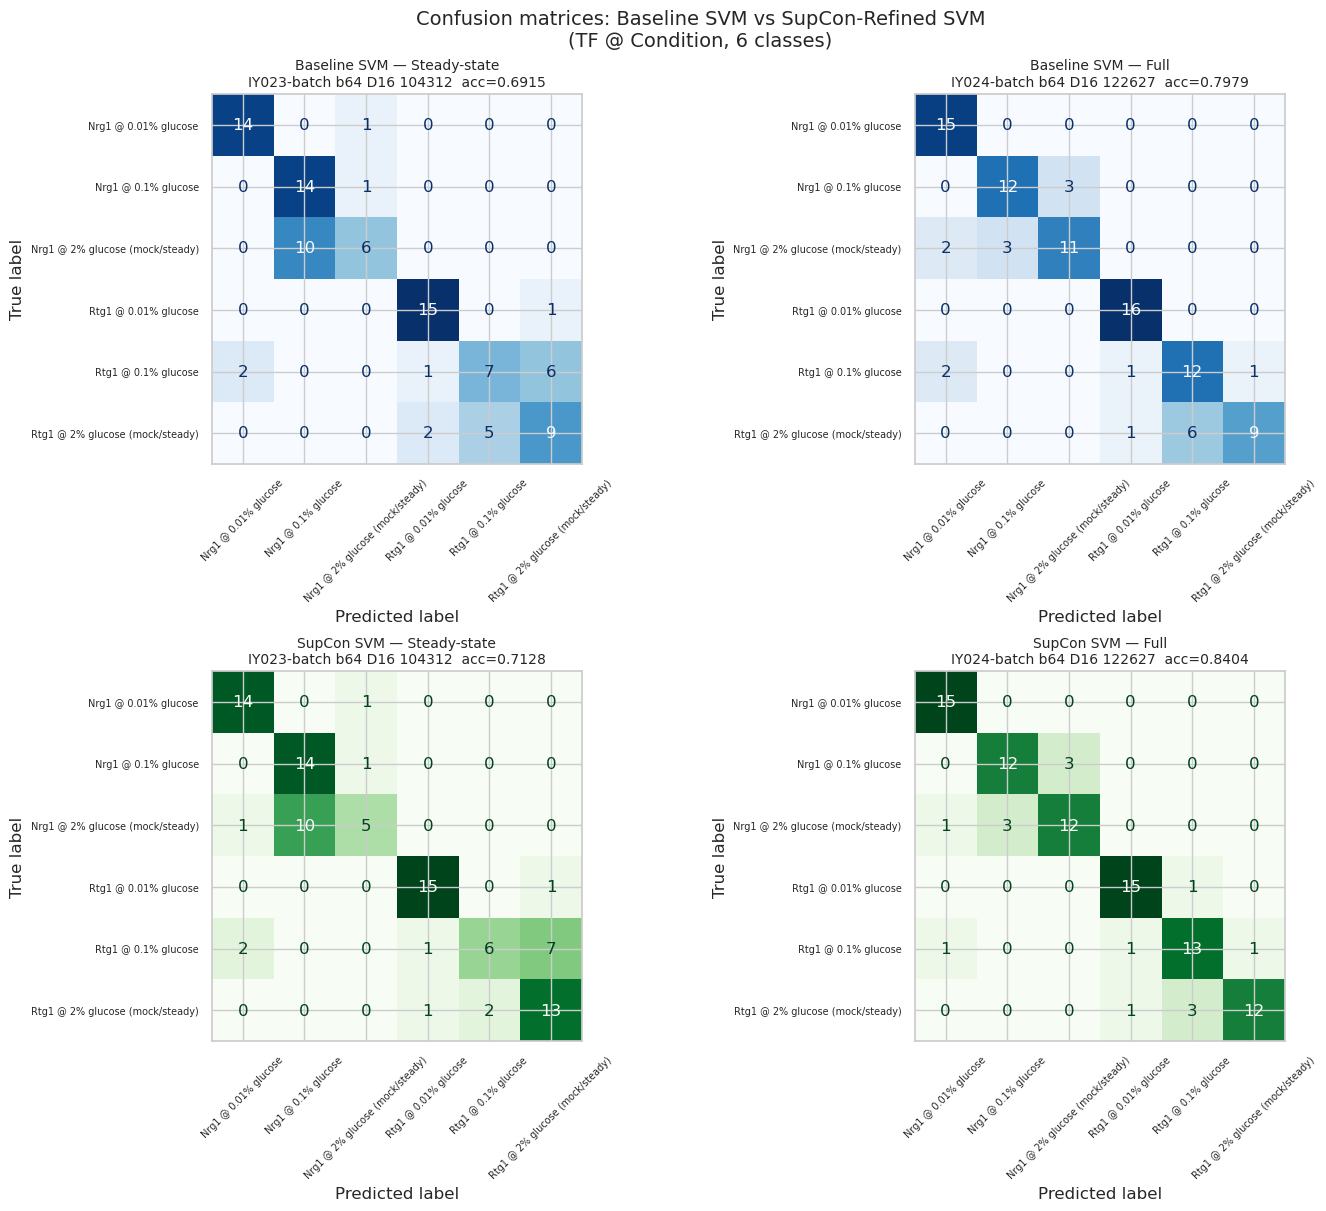

In [11]:
def best_preds(df, preds_dict, head):
    v   = ok(df)
    row = v.loc[v[f"{head}_acc"].idxmax()]
    return preds_dict[row["checkpoint"]][head], row["label"], row[f"{head}_acc"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
entries = [
    (axes[0,0], ss,   *best_preds(ss_df,   ss_preds,   "baseline"), "Baseline SVM", "Steady-state", "Blues"),
    (axes[0,1], full, *best_preds(full_df, full_preds, "baseline"), "Baseline SVM", "Full",         "Blues"),
    (axes[1,0], ss,   *best_preds(ss_df,   ss_preds,   "supcon"),   "SupCon SVM",  "Steady-state", "Greens"),
    (axes[1,1], full, *best_preds(full_df, full_preds, "supcon"),   "SupCon SVM",  "Full",         "Greens"),
]
for ax, d, y_pred, ckpt_label, acc, head, dataset_tag, cmap in entries:
    ConfusionMatrixDisplay.from_predictions(
        d["y_test"], y_pred, display_labels=d["class_names"],
        ax=ax, colorbar=False, cmap=cmap,
    )
    ax.set_title(f"{head} — {dataset_tag}\n{ckpt_label}  acc={acc:.4f}", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
fig.suptitle("Confusion matrices: Baseline SVM vs SupCon-Refined SVM\n"
             "(TF @ Condition, 6 classes)", fontsize=14)
fig.savefig(IY034_DIR / "IY034_confusion_matrices.png", dpi=150, bbox_inches="tight")
print("Saved: IY034_confusion_matrices.png")
plt.show()

## 11. Detailed Classification Reports

In [12]:
for dataset_tag, d, df, preds_dict in [
    ("Steady-state", ss,   ss_df,   ss_preds),
    ("Full",         full, full_df, full_preds),
]:
    print(f"\n{'='*60}\n{dataset_tag}\n{'='*60}")
    for head, label in [("baseline", "Baseline SVM (IY031)"),
                        ("supcon",   "SupCon-refined SVM (IY034)")]:
        y_pred, ckpt_lbl, acc = best_preds(df, preds_dict, head)
        print(f"\n--- {label} — {ckpt_lbl} (acc={acc:.4f}) ---")
        print(classification_report(d["y_test"], y_pred, target_names=d["class_names"]))


Steady-state

--- Baseline SVM (IY031) — IY023-batch b64 D16 104312 (acc=0.6915) ---
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       0.88      0.93      0.90        15
            Nrg1 @ 0.1% glucose       0.58      0.93      0.72        15
Nrg1 @ 2% glucose (mock/steady)       0.75      0.38      0.50        16
           Rtg1 @ 0.01% glucose       0.83      0.94      0.88        16
            Rtg1 @ 0.1% glucose       0.58      0.44      0.50        16
Rtg1 @ 2% glucose (mock/steady)       0.56      0.56      0.56        16

                       accuracy                           0.69        94
                      macro avg       0.70      0.70      0.68        94
                   weighted avg       0.70      0.69      0.67        94


--- SupCon-refined SVM (IY034) — IY023-batch b64 D16 104312 (acc=0.7128) ---
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% gluco